# 05 — Breakout hunting

## Step 5A — Defining a breakout (candidates)

A breakout is defined by what happens in a season **relative to the player's own past** (previous 3 seasons played, weighted by minutes), not relative to last season alone. That stops injury comebacks looking like breakouts (Hayward 2018-19 vs a 1-game season). When we predict from season *t*, the label comes from *t*+1 or later: **labels are outcomes, never features.**

| Candidate | Definition (season must be ≥ 1,200 min, scaled to 82 games) |
|---|---|
| **Production** | Overall impact (PIE z) rises ≥ 1.0 above his own past, *beyond what is normal for his age*, and ends ≥ 0.5 above an average rotation player |
| **Role** | ≥ 6 more minutes per game than his past, usage up ≥ 0.5 SD, efficiency (shrunk TS% z) down no more than 0.5 |
| **Scoring** | ≥ 5 more points per game than his past, ≥ 15 ppg, efficiency holds |
| **Star (season)** | Top 5% of that season's rotation players by PIE, ≥ 1,500 min |

"Normal for his age" uses the age curve from notebook 03, **frozen on 2011-16 only**, so later seasons can't shape earlier labels.

**External check:** the NBA's Most Improved Player (MIP) winners, the league's own breakout award ([source](https://en.wikipedia.org/wiki/NBA_Most_Improved_Player_Award)). Used **only for validation**; MIP voting is known to reward points per game.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unicorn.labels import add_labels, add_future, MIP_WINNERS
from unicorn.plotting import apply_style, BLUE, ORANGE, INK, INK2, MUTED, FIG_DIR, SERIES, SURFACE
from unicorn.raw import PROJECT_ROOT

apply_style()
uni = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_unicorn.parquet")
lab = add_labels(uni)
LABELS = ["breakout_production", "breakout_role", "breakout_scoring", "breakout_any"]
young = lab["age"] <= 25

summary = pd.DataFrame({
    "seasons": [lab[c].sum() for c in LABELS],
    "rate_all": [lab[c].mean() for c in LABELS],
    "rate_age≤25": [lab.loc[young, c].mean() for c in LABELS],
    "MIP_captured": [f"{lab.loc[lab['mip'], c].sum()}/{len(MIP_WINNERS)}" for c in LABELS],
    "MIP_missed": [", ".join(lab.loc[lab["mip"] & ~lab[c], "player_name"]) for c in LABELS],
}, index=[c.replace("breakout_", "") for c in LABELS])
summary.style.format({"rate_all": "{:.1%}", "rate_age≤25": "{:.1%}"})

,seasons,rate_all,rate_age≤25,MIP_captured,MIP_missed
production,75,1.0%,0.9%,6/15,"Ryan Anderson, Goran Dragic, Paul George, Julius Randle, Pascal Siakam, Ja Morant, Nickeil Alexander-Walker, Tyrese Maxey, Dyson Daniels"
role,119,1.5%,2.6%,6/15,"Ryan Anderson, Goran Dragic, Paul George, Victor Oladipo, Giannis Antetokounmpo, Julius Randle, Brandon Ingram, Lauri Markkanen, Ja Morant"
scoring,196,2.5%,3.7%,11/15,"Ryan Anderson, Paul George, Julius Randle, Dyson Daniels"
any,308,3.9%,5.6%,12/15,"Ryan Anderson, Paul George, Julius Randle"


In [2]:
print("How much do the definitions overlap? (player-seasons)")
pd.crosstab([lab["breakout_production"], lab["breakout_role"]], lab["breakout_scoring"])

How much do the definitions overlap? (player-seasons)


breakout_scoring                   False  True 
breakout_production breakout_role              
False               False           7581    123
                    True              62     48
True                False             45     21
                    True               5      4

### Who gets labelled? Top examples of each

In [3]:
cols = ["player_name", "season", "age", "pie_z", "pie_excess_vs_age", "min_per_game", "min_per_game_vs_past",
        "usg_pct_z_vs_past", "ppg", "ppg_vs_past", "ts_pct_shr_z_vs_past"]
for c, sort in [("breakout_production", "pie_excess_vs_age"), ("breakout_role", "min_per_game_vs_past"), ("breakout_scoring", "ppg_vs_past")]:
    print(c)
    display(lab[lab[c] & young].nlargest(10, sort)[cols].round(2))

breakout_production


,player_name,season,age,pie_z,pie_excess_vs_age,min_per_game,min_per_game_vs_past,usg_pct_z_vs_past,ppg,ppg_vs_past,ts_pct_shr_z_vs_past
3499,Rudy Gobert,2014-15,22.60,2.16,1.85,26.32,16.68,0.06,8.37,6.05,2.47
4603,Domantas Sabonis,2018-19,22.75,2.03,1.80,24.84,2.43,0.79,14.09,5.45,2.09
2161,Larry Sanders,2012-13,24.20,0.89,1.72,27.29,14.93,0.07,9.80,6.23,0.98
3580,Giannis Antetokounmpo,2016-17,22.16,2.55,1.66,35.56,4.43,1.72,22.90,10.69,0.86
4602,Domantas Sabonis,2017-18,21.75,0.79,1.60,24.46,4.32,1.15,11.64,5.72,2.13
2179,Eric Bledsoe,2012-13,23.15,0.99,1.56,20.43,8.85,0.63,8.46,5.16,0.60
3342,Dennis Schröder,2014-15,21.38,0.57,1.55,19.69,6.60,1.63,9.97,6.24,1.37
2067,DeMarcus Cousins,2013-14,23.47,2.90,1.50,32.37,1.87,0.87,22.73,5.18,0.89
3582,Giannis Antetokounmpo,2018-19,24.16,3.75,1.38,32.75,-3.11,0.91,27.69,5.58,1.10
4626,Marquese Chriss,2019-20,22.58,0.91,1.32,20.27,0.31,-0.06,9.29,1.72,1.55


breakout_role


,player_name,season,age,pie_z,pie_excess_vs_age,min_per_game,min_per_game_vs_past,usg_pct_z_vs_past,ppg,ppg_vs_past,ts_pct_shr_z_vs_past
5597,Devonte' Graham,2019-20,24.94,0.37,1.00,35.10,20.40,1.42,18.17,13.46,1.08
3319,CJ McCollum,2015-16,24.37,0.50,1.14,34.75,20.09,1.37,20.82,14.58,0.32
6314,Isaiah Roby,2020-21,23.00,-0.43,2.61,23.37,19.57,1.85,8.74,8.74,-0.29
7322,Ryan Rollins,2025-26,23.58,0.44,0.44,32.10,18.78,0.87,17.31,12.18,-0.15
5246,Derrick White,2018-19,24.59,0.00,-1.11,25.79,17.63,0.63,9.90,6.72,-0.26
3016,Tony Wroten,2013-14,20.80,-0.44,0.86,24.51,16.74,1.38,13.04,10.44,-0.42
5331,Monte Morris,2018-19,23.60,0.52,-2.01,24.03,15.60,0.63,10.38,7.04,0.65
2605,Reggie Jackson,2013-14,23.80,0.64,0.26,28.47,15.31,0.78,13.09,8.62,0.28
2180,Eric Bledsoe,2013-14,24.15,1.52,0.73,32.94,14.54,0.64,17.74,11.06,1.42
2946,Kendall Marshall,2013-14,22.46,-0.04,0.66,28.96,14.33,0.62,7.96,4.98,-0.02


breakout_scoring


,player_name,season,age,pie_z,pie_excess_vs_age,min_per_game,min_per_game_vs_past,usg_pct_z_vs_past,ppg,ppg_vs_past,ts_pct_shr_z_vs_past
3319,CJ McCollum,2015-16,24.37,0.50,1.14,34.75,20.09,1.37,20.82,14.58,0.32
5597,Devonte' Graham,2019-20,24.94,0.37,1.00,35.10,20.40,1.42,18.17,13.46,1.08
6959,Cam Thomas,2023-24,22.30,0.30,-0.15,31.44,14.30,1.09,22.45,12.99,0.07
7322,Ryan Rollins,2025-26,23.58,0.44,0.44,32.10,18.78,0.87,17.31,12.18,-0.15
6928,Jalen Johnson,2023-24,22.12,0.69,0.10,33.73,19.82,0.46,16.00,11.14,0.49
2180,Eric Bledsoe,2013-14,24.15,1.52,0.73,32.94,14.54,0.64,17.74,11.06,1.42
4835,Pascal Siakam,2018-19,24.84,0.86,0.90,31.85,12.84,1.17,16.92,10.91,1.90
4618,Malik Beasley,2020-21,24.18,0.12,0.33,32.81,12.21,0.90,19.57,10.84,-0.19
3580,Giannis Antetokounmpo,2016-17,22.16,2.55,1.66,35.56,4.43,1.72,22.90,10.69,0.86
6539,Tyrese Maxey,2023-24,23.24,1.09,0.50,37.51,6.14,1.06,25.94,10.55,-0.43


### Shai and LaMelo under each definition

In [4]:
for name in ["Shai Gilgeous-Alexander", "LaMelo Ball"]:
    print(name)
    display(lab.loc[lab["player_name"] == name, ["season", "age", "pie_z", "pie_excess_vs_age", "min_per_game_vs_past",
                                                "ppg", "ppg_vs_past", *LABELS, "star_season_pie"]].round(2))

Shai Gilgeous-Alexander


,season,age,pie_z,pie_excess_vs_age,min_per_game_vs_past,ppg,ppg_vs_past,breakout_production,breakout_role,breakout_scoring,breakout_any,star_season_pie
5588,2018-19,20.56,-0.40,NaN,NaN,10.84,NaN,False,False,False,False,False
5589,2019-20,21.56,0.79,0.52,8.18,19.01,8.17,False,True,True,True,False
5590,2020-21,22.56,1.57,0.82,2.88,23.71,9.11,False,False,True,True,False
5591,2021-22,23.56,1.22,0.43,3.26,24.48,8.17,False,False,True,True,False
5592,2022-23,24.56,2.47,1.15,1.05,31.40,9.46,True,False,True,True,True
5593,2023-24,25.56,2.99,0.97,-0.81,30.05,2.78,False,False,False,False,True
5594,2024-25,26.56,3.41,1.07,-0.56,32.68,3.74,True,False,False,True,True
5595,2025-26,27.56,3.60,0.64,-1.34,31.13,-0.25,False,False,False,False,True


LaMelo Ball


,season,age,pie_z,pie_excess_vs_age,min_per_game_vs_past,ppg,ppg_vs_past,breakout_production,breakout_role,breakout_scoring,breakout_any,star_season_pie
6453,2020-21,19.45,0.76,NaN,NaN,15.75,NaN,False,False,False,False,False
6454,2021-22,20.45,1.15,0.17,3.50,20.11,4.36,False,False,False,False,False
6455,2022-23,21.45,0.82,-0.86,4.24,23.28,4.94,False,False,False,False,False
6456,2023-24,22.44,1.22,-0.25,0.32,23.91,4.47,False,False,False,False,False
6457,2024-25,23.45,0.99,-0.36,-1.13,25.19,3.60,False,False,False,False,False
6458,2025-26,24.45,1.19,-0.00,-5.22,20.07,-4.20,False,False,False,False,False


### Problem: a PIE-based "star" definition favours big men

Compare the position mix of PIE-star seasons with the position mix of rotation players.

,PIE-star seasons
Devin Booker,0
Donovan Mitchell,2
Anthony Edwards,0
Jalen Brunson,1
Jaylen Brown,1
Kyrie Irving,2
LaMelo Ball,0
Hassan Whiteside,4
Jonas Valančiūnas,2
Jarrett Allen,2


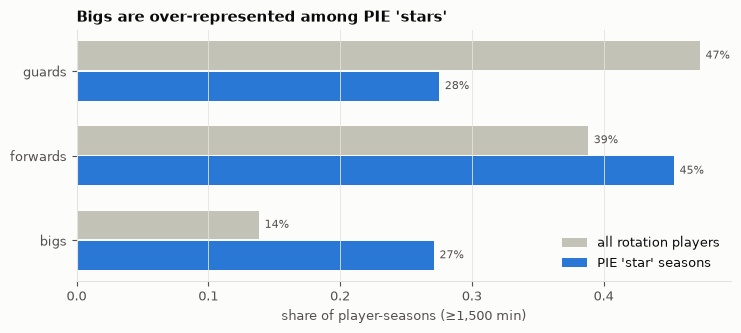

In [5]:
rot = lab[lab["min_scaled"] >= 1500].copy()
rot["group"] = pd.cut(rot["position_num"], [0, 2.0, 3.5, 5.0], labels=["guards", "forwards", "bigs"])
mix = pd.DataFrame({"all rotation players": rot["group"].value_counts(normalize=True),
                    "PIE 'star' seasons": rot.loc[rot["star_season_pie"], "group"].value_counts(normalize=True)}).loc[["guards", "forwards", "bigs"]]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
y = np.arange(len(mix))
for k, (col, color) in enumerate(zip(mix.columns, [MUTED, BLUE])):
    ax.barh(y + (k - 0.5) * 0.36, mix[col], height=0.34, color=color, label=col)
    for yi, v in zip(y, mix[col]):
        ax.annotate(f"{v:.0%}", (v, yi + (k - 0.5) * 0.36), xytext=(4, 0), textcoords="offset points", va="center", color=INK2, fontsize=8)
ax.set_yticks(y, mix.index); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("share of player-seasons (≥1,500 min)"); ax.legend(frameon=False, loc="lower right")
ax.set_title("Bigs are over-represented among PIE 'stars'", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "05_pie_star_position_bias.png", dpi=150, bbox_inches="tight")

stars = lab[lab["star_season_pie"]].groupby("player_name").size()
check = ["Devin Booker", "Donovan Mitchell", "Anthony Edwards", "Jalen Brunson", "Jaylen Brown", "Kyrie Irving", "LaMelo Ball",
         "Hassan Whiteside", "Jonas Valančiūnas", "Jarrett Allen", "Al Jefferson", "Enes Freedom"]
pd.Series({n: int(stars.get(n, 0)) for n in check}, name="PIE-star seasons").to_frame()

### How often does a young player who isn't yet a star become one within 3 seasons? (PIE definition)

In [6]:
lab = add_future(lab, ["star_season_pie", *LABELS], horizon=1)
lab = add_future(lab, ["star_season_pie"], horizon=3)
pop = lab[(lab["age"] <= 23) & (lab["pie_pctl"] < 0.9) & lab["observable_next3"]]
print(f"population: {len(pop)} player-seasons; became a PIE-star within 3 seasons: {pop['star_season_pie_next3'].mean():.1%} "
      f"({pop['star_season_pie_next3'].sum()} cases, {pop.loc[pop['star_season_pie_next3'], 'player_name'].nunique()} players)")
print("next-season breakout rates for players aged ≤ 25 (observable rows):")
obs = lab[young & lab["observable_next1"]]
obs[[f"{c}_next1" for c in LABELS]].mean().round(3)

population: 1232 player-seasons; became a PIE-star within 3 seasons: 3.3% (41 cases, 24 players)
next-season breakout rates for players aged ≤ 25 (observable rows):


breakout_production_next1    0.013
breakout_role_next1          0.032
breakout_scoring_next1       0.047
breakout_any_next1           0.070
dtype: float64

### Step 5A findings (candidates, not yet chosen)

| Label | Player-seasons | Rate (age ≤ 25) | MIP winners captured | Character |
|---|---|---|---|---|
| Production | 75 | 0.9% | 6/15 | big jump in all-round impact; leans to bigs (Gobert 2014-15, Sabonis, Larry Sanders) because PIE does |
| Role | 119 | 2.6% | 6/15 | sudden promotion (Devonte' Graham, CJ McCollum, Derrick White) |
| Scoring | 196 | 3.7% | **11/15** | points jump with efficiency held (McCollum, Siakam, Maxey, Giannis 2016-17) |
| Any of the three | 308 | 5.6% | **12/15** | misses only Ryan Anderson, Paul George, Julius Randle |

- **The three labels capture different things.** Most player-seasons are labelled by only one of them.
- **Shai** is labelled in year 2 (role + scoring), years 3–4 (scoring), year 5 (production + scoring) and year 7 (production). **LaMelo is never labelled**: his growth was steady (about +4 ppg a year), never a jump, although he was an All-Star in 2022.
- **A PIE-based star definition is biased toward bigs.** Bigs are 14% of rotation players but 27% of PIE-star seasons, and guards 47% vs 28%. The PIE-star list includes Whiteside (4 seasons), Al Jefferson, Valančiūnas and Jarrett Allen, but Devin Booker and Anthony Edwards have **zero** PIE-star seasons.
- Next-season breakout rates for players ≤ 25 are 1–5% depending on the label, so **these are rare-event prediction problems**. Evaluation must use precision/recall and ranking metrics, not accuracy.
- PIE-star within 3 seasons, among young non-stars: 3.3% (41 cases, 24 players).

## Step 5B — Our own star metric

PIE favours bigs, and media awards have their own biases, so we build our own. A **star season** is judged **only from that season's numbers**: no reputation, awards, draft position or future.

**Six pillars**, each an average of season-relative z-scores:

| Pillar | Ingredients |
|---|---|
| scoring | points per 36, efficiency (shrunk TS%) |
| creation | assist %, minus half of turnover % |
| rebounding | offensive + defensive rebound % |
| defense | steals and blocks per 100 possessions, minus on-court defensive rating |
| impact | PIE, on-court net rating |
| trust | minutes per game (how much his coach relies on him) |

`star_score` = mean of the six pillars. **Size-fairness dial:** each pillar is blended between its raw value and its value *relative to players of the same body size* (so a center gets less automatic credit for rebounding). 0 = raw, 1 = fully size-relative. **Star season** = top 5% of that season's players with ≥ 1,500 minutes.

,guards_share,forwards_share,bigs_share,Joel Embiid,Nikola Jokić,Rudy Gobert,Jayson Tatum,Donovan Mitchell,Devin Booker,Anthony Edwards
size_adjustment,,,,,,,,,,
0.00,0.24,0.50,0.27,6,9,6,2,0,0,0
0.25,0.28,0.51,0.21,6,9,4,4,1,0,0
0.50,0.33,0.50,0.18,5,8,1,5,1,0,0
0.75,0.37,0.52,0.10,2,6,0,5,2,0,0
1.00,0.43,0.50,0.07,0,6,0,5,2,0,1


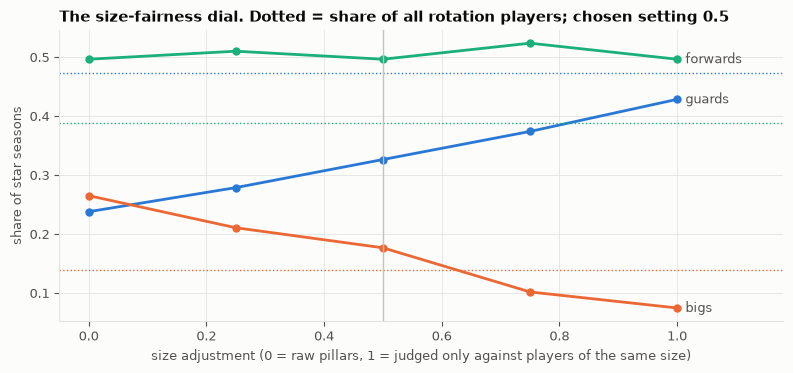

In [7]:
from unicorn.labels import add_star_score

rot = lab[lab["min_scaled"] >= 1500]
groups = pd.cut(lab["position_num"], [0, 2.0, 3.5, 5.0], labels=["guards", "forwards", "bigs"])
base_mix = groups[rot.index].value_counts(normalize=True)

dial = []
for a in [0, 0.25, 0.5, 0.75, 1.0]:
    s = add_star_score(lab, size_adjustment=a)
    stars = s[s["star_season"]]
    mix = groups[stars.index].value_counts(normalize=True)
    per_player = stars.groupby("player_name").size()
    dial.append({"size_adjustment": a, **{f"{g}_share": mix.get(g, 0) for g in ["guards", "forwards", "bigs"]},
                 **{n: int(per_player.get(n, 0)) for n in ["Joel Embiid", "Nikola Jokić", "Rudy Gobert", "Jayson Tatum",
                                                           "Donovan Mitchell", "Devin Booker", "Anthony Edwards"]}})
dial = pd.DataFrame(dial).set_index("size_adjustment")

fig, ax = plt.subplots(figsize=(8, 3.8))
for g, color in [("guards", SERIES[0]), ("forwards", SERIES[2]), ("bigs", SERIES[1])]:
    ax.plot(dial.index, dial[f"{g}_share"], color=color, marker="o", markersize=5)
    ax.axhline(base_mix[g], color=color, linewidth=1, linestyle=":")
    ax.annotate(f"{g}", (1.0, dial[f"{g}_share"].iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", color=INK2)
ax.axvline(0.5, color=MUTED, linewidth=1)
ax.set_xlabel("size adjustment (0 = raw pillars, 1 = judged only against players of the same size)")
ax.set_ylabel("share of star seasons"); ax.set_xlim(-0.05, 1.18)
ax.set_title("The size-fairness dial. Dotted = share of all rotation players; chosen setting 0.5", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "05_star_size_dial.png", dpi=150, bbox_inches="tight")
dial.round(2)

In [8]:
lab = add_star_score(lab)   # size_adjustment = 0.5
stars = lab[lab["star_season"]]
print(f"{len(stars)} star seasons, {stars['player_name'].nunique()} players")
stars.groupby("player_name").size().sort_values(ascending=False).head(30).to_frame("star seasons")

147 star seasons, 48 players


,star seasons
player_name,
LeBron James,10
James Harden,10
Anthony Davis,9
Giannis Antetokounmpo,9
Kawhi Leonard,8
Nikola Jokić,8
Stephen Curry,8
Russell Westbrook,8
Luka Dončić,7


In [9]:
print("2025-26 top 15 by star score:")
display(lab[(lab["season"] == "2025-26") & (lab["min_scaled"] >= 1500)].nlargest(15, "star_score")
        [["player_name", "star_score", "star_pctl", *[c for c in lab.columns if c.startswith("pillar_")]]].round(2))
for name in ["Shai Gilgeous-Alexander", "LaMelo Ball"]:
    print(name, lab.loc[lab["player_name"] == name, ["season", "star_pctl"]].set_index("season")["star_pctl"].round(2).to_dict())

2025-26 top 15 by star score:


,player_name,star_score,star_pctl,pillar_scoring,pillar_creation,pillar_rebounding,pillar_defense,pillar_impact,pillar_trust
5595,Shai Gilgeous-Alexander,1.57,1.00,2.70,1.79,-0.51,0.93,3.07,1.43
4108,Nikola Jokić,1.51,0.99,1.85,2.38,1.09,-0.20,2.29,1.68
7489,Victor Wembanyama,1.31,0.99,1.45,0.25,0.89,1.83,2.62,0.83
5823,Luka Dončić,1.28,0.98,2.03,1.94,0.12,0.03,1.78,1.78
2538,Kawhi Leonard,1.16,0.98,2.01,0.73,0.25,0.66,2.06,1.23
7056,Cade Cunningham,1.12,0.97,0.70,2.11,-0.19,0.68,1.92,1.52
7238,Jalen Duren,1.07,0.96,1.89,-0.30,1.79,0.34,2.02,0.65
6930,Jalen Johnson,0.97,0.96,0.62,1.28,0.96,-0.08,1.32,1.69
7205,Chet Holmgren,0.94,0.95,1.16,-0.35,0.78,1.31,1.97,0.75
6541,Tyrese Maxey,0.91,0.95,1.18,1.13,-0.51,0.43,1.03,2.21


Shai Gilgeous-Alexander {'2018-19': 0.26, '2019-20': 0.75, '2020-21': nan, '2021-22': 0.81, '2022-23': 0.96, '2023-24': 0.99, '2024-25': 1.0, '2025-26': 1.0}
LaMelo Ball {'2020-21': 0.72, '2021-22': 0.87, '2022-23': nan, '2023-24': nan, '2024-25': 0.79, '2025-26': 0.9}


### Star outcome for prediction

The *star season* uses only that season. **Predicting** whether a player *will become* a star is necessarily about the future, which is exactly what the backtest tests. The model's inputs will only ever use seasons ≤ *t*. The prediction population will include **everyone** (undrafted, late picks, low-minute players), so in principle anyone can become a star.

In [10]:
lab = add_future(lab, ["star_season"], horizon=3)
pop = lab[(lab["age"] <= 25) & (lab["star_pctl"].fillna(0) < 0.90) & lab["observable_next3"]]
hit = pop["star_season_next3"]
print(f"young (≤25) non-stars: {len(pop)} player-seasons; became a star within 3 seasons: {hit.mean():.1%} "
      f"({hit.sum()} cases, {pop.loc[hit, 'player_name'].nunique()} players)")
pop.loc[hit].groupby("player_name")["season"].min().sort_values().to_frame("first flagged from")

young (≤25) non-stars: 2521 player-seasons; became a star within 3 seasons: 1.8% (46 cases, 26 players)


,first flagged from
player_name,
DeAndre Jordan,2011-12
DeMarcus Cousins,2011-12
Kawhi Leonard,2011-12
Stephen Curry,2011-12
Anthony Davis,2012-13
Draymond Green,2012-13
Kevin Love,2012-13
Giannis Antetokounmpo,2013-14
Rudy Gobert,2013-14


### Step 5B findings

- **Size-fairness dial at 0.5:** guards 33% of star seasons (47% of rotation players), forwards 50% (39%), bigs 18% (14%). Much closer to fair than PIE (bigs 27%) without erasing dominant bigs (Embiid 5 star seasons, Jokić 8). At 1.0 Embiid disappears entirely.
- **147 star seasons, 48 players.** Leaders: LeBron, Harden (10), Davis, Giannis (9), Kawhi, Jokić, Curry, Westbrook (8), Luka, Chris Paul (7), Durant (6), Tatum, Embiid (5), Shai (4).
- **2025-26 top 5:** Shai, Jokić, Wembanyama, Dončić, Kawhi.
- **Shai:** 26th → 75th → 81st → **96th** percentile (a star from 2022-23). **LaMelo** peaks at the 90th (2025-26), close to but never top 5%.
- **What it doesn't reward:** one-dimensional scorers. Booker, Edwards and Brunson rarely or never qualify, because scoring is 1 of 6 pillars. This is a deliberate consequence of an all-round definition and is open to change (e.g. weight scoring and creation more).
- **Watch-out:** the impact pillar includes on-court net rating, which reflects team quality. A few defensive bigs on good teams appear among future stars (Capela, Zubac, Robert Williams III).
- **Star prediction is rare:** 1.8% of young non-star seasons are followed by a star season within 3 years (46 cases, 26 players). Seasons under 1,500 minutes (injury) can't be star seasons, e.g. Shai 2020-21.